**SALES DATA ANALYSIS:**

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("sales_dataset.csv")
df.head()



,Unnamed: 0,OrderID,CustomerID,Region,Product,Category,Quantity,Price,TotalSales,OrderDate,year
0,0,bc6566ab-f553-407a-ad19-c411a53445e4,9ade37c6-79db-4e9f-a1d3-d5fafc1b8911,North,Tablet,Electronics,126,454.19,57227.94,2024-11-15,2024
1,1,cd57b082-60e0-417f-befc-acd9a986b542,27d11f45-2466-4992-9b73-44096bdddf71,North,Smartwatch,Electronics,217,73.25,15895.25,2022-05-08,2022
2,2,0c0b1115-a076-4a61-a421-590802110d5c,7a484f85-2993-4504-bd07-34392fb43aa7,North,Table,Furniture,259,1208.02,312877.18,2024-12-05,2024
3,3,40cfbe52-5f11-4d3e-9334-6b2c61c9d2d7,fc157279-55a2-4b54-92a2-4cbf503429e1,South,Microwave,Home Appliances,230,1182.64,272007.20,2023-12-14,2023
4,4,3ee1faef-ef08-4bca-b801-92816e22838d,8ff40b0b-224a-4f12-9914-154b3c77f6e2,North,Bed,Furniture,175,562.96,98518.00,2024-05-25,2024


In [8]:
print(df.shape)

(500, 11)


In [9]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  500 non-null    int64  
 1   OrderID     500 non-null    object 
 2   CustomerID  500 non-null    object 
 3   Region      500 non-null    object 
 4   Product     500 non-null    object 
 5   Category    500 non-null    object 
 6   Quantity    500 non-null    int64  
 7   Price       500 non-null    float64
 8   TotalSales  500 non-null    float64
 9   OrderDate   500 non-null    object 
 10  year        500 non-null    int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 43.1+ KB


In [10]:
df.isnull().sum()

Unnamed: 0    0
OrderID       0
CustomerID    0
Region        0
Product       0
Category      0
Quantity      0
Price         0
TotalSales    0
OrderDate     0
year          0
dtype: int64

In [11]:
df.describe() 

,Unnamed: 0,Quantity,Price,TotalSales,year
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,152.946000,980.050240,146770.989660,2022.944000
std,144.481833,87.662812,572.593943,129671.600867,0.880007
min,0.000000,1.000000,13.370000,614.710000,2021.000000
25%,124.750000,73.750000,493.772500,39176.475000,2022.000000
50%,249.500000,152.000000,1002.160000,109335.820000,2023.000000
75%,374.250000,231.000000,1456.572500,236854.882500,2024.000000
max,499.000000,300.000000,1999.820000,576928.720000,2024.000000


In [12]:
df["OrderDate"]=pd.to_datetime(df["OrderDate"]) 
df["OrderDate"].head()

0   2024-11-15
1   2022-05-08
2   2024-12-05
3   2023-12-14
4   2024-05-25
Name: OrderDate, dtype: datetime64[ns]

In [13]:
df["Month"]=df["OrderDate"].dt.month_name() 
df[["OrderDate","Month"]].head()

,OrderDate,Month
0,2024-11-15,November
1,2022-05-08,May
2,2024-12-05,December
3,2023-12-14,December
4,2024-05-25,May


In [14]:
df["TotalSales"].sum() 

73385494.83000001

In [15]:
df.groupby("Region")["TotalSales"].sum() 

Region
East     20703813.19
North    16739874.39
South    18119267.44
West     17822539.81
Name: TotalSales, dtype: float64

In [16]:
df.groupby("Category")["TotalSales"].sum() 

Category
Clothing           16420800.06
Electronics        17013922.29
Furniture          17653327.07
Home Appliances    22297445.41
Name: TotalSales, dtype: float64

In [22]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10) 

Product
Microwave          5022
Vacuum Cleaner     4895
Air Conditioner    4767
T-Shirt            4653
Washing Machine    4645
Headphones         4488
Tablet             4395
Table              4145
Bed                3941
Shirt              3737
Name: Quantity, dtype: int64

In [30]:
df.groupby("Product")["TotalSales"].sum().sort_values(ascending=False).head(10)

Product
Washing Machine    5292590.85
Vacuum Cleaner     4818765.01
Air Conditioner    4770957.37
Tablet             4729672.39
Microwave          4687735.02
Headphones         4682286.13
Table              4344352.78
Dress              3918250.72
T-Shirt            3875733.22
Sofa               3739934.60
Name: TotalSales, dtype: float64

In [19]:
df.groupby("Month")["TotalSales"].sum()

Month
April        5382788.46
August       6000412.69
December     9683643.19
February     6087448.59
January      4969086.60
July         6022710.02
June         6615089.38
March        4381790.96
May          5919469.73
November     7023677.26
October      5511273.63
September    5788104.32
Name: TotalSales, dtype: float64

In [23]:
df.groupby("CustomerID")["TotalSales"].sum().sort_values(ascending=False).head()

CustomerID
8c2456d6-79a4-428c-b4d1-21eaa68c417a    576928.72
b67bb750-c95a-4688-8a93-8d2a8b9876ec    575754.47
e191bff5-079a-457a-9cc1-c91d33f9907f    567798.00
ee01ed8a-6169-49c9-b172-129956a27534    548741.64
28d58014-10d1-470c-b533-58ed721809fa    542133.28
Name: TotalSales, dtype: float64

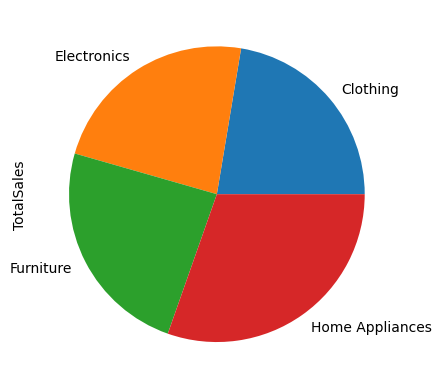

In [24]:
cat=df.groupby("Category")["TotalSales"].sum() 
cat.plot(kind="pie") 
plt.show()

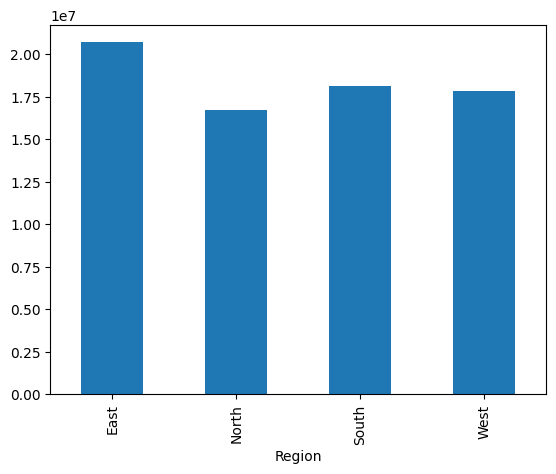

In [25]:
region=df.groupby("Region")["TotalSales"].sum()
region.plot(kind="bar") 
plt.show()

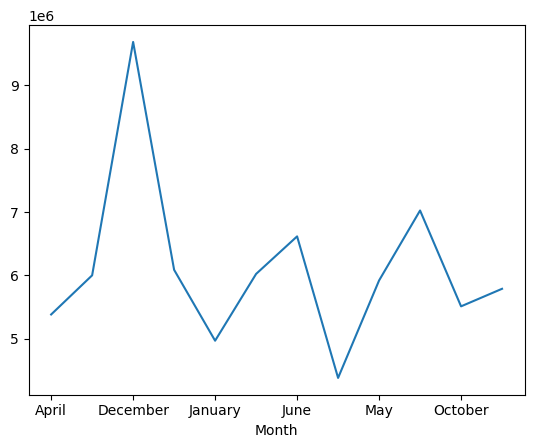

In [26]:
month=df.groupby("Month")["TotalSales"].sum()
month.plot(kind="line")
plt.show()

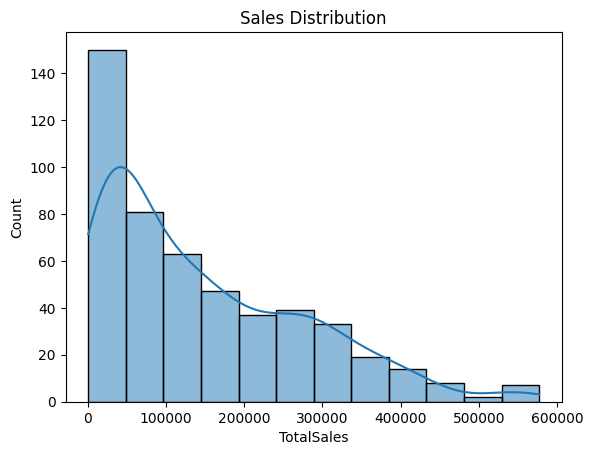

In [27]:
sns.histplot(df['TotalSales'], kde=True)
plt.title("Sales Distribution")
plt.show()

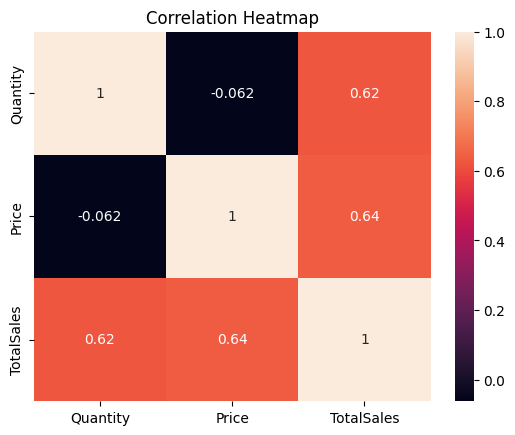

In [28]:
sns.heatmap(df[['Quantity','Price','TotalSales']].corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

**INSIGHTS:**
- The dataset is clean and reliable with no missing values or duplicate records.
- Sales performance varies across different regions.
- Certain product categories generate higher sales than others.
- A few products contribute significantly to total revenue.
- Higher quantity sold leads to increased total sales.
- Product price has a positive impact on sales revenue.
- These insights can help improve inventory planning and business decision- making.